# AutoIntel AI — Vehicle Maintenance Dataset
## Data Analysis, Preprocessing & Feature Engineering Pipeline

**Module Owner:** Member 1 — Vehicle Maintenance Engineer
**Dataset:** `vehicle_maintenance_clean_with_id.csv`
**Position in Architecture:** feeds the *Vehicle Maintenance History* module of the Final Diagnosis Report, alongside the Repair Knowledge dataset (Member 3) and the OBD-II Knowledge dataset (Member 2).

**Notebook Objectives**
1. Perform a rigorous, column-by-column audit of the raw dataset (purpose, dtype, business meaning, quality risks).
2. Apply only the preprocessing that the data actually needs — and justify every step, including steps that are *skipped*.
3. Engineer automotive-domain features that make this dataset genuinely useful for ML, dashboards, and SQL-based lookups.
4. Produce a clean, well-typed, SQL-ready output table with a documented schema.

**Guiding principle:** every transformation below is justified from evidence gathered by inspecting the data — nothing is assumed.


---
## 0. Setup & Configuration

We load standard data-science libraries and set global configuration. We deliberately avoid hard-coding "today's date" for maintenance-recency features — see the discussion in Section 4.1, where we define an explicit, justified **reference date** instead of silently assuming one.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RAW_PATH = "vehicle_maintenance_clean_with_id.csv"
OUTPUT_PATH = "vehicle_maintenance_final_sql_ready.csv"

print("Environment ready.")


Environment ready.


---
## 1. Load Data & First Look

**Objective:** get a factual baseline (shape, dtypes, sample rows) before making any decisions.


In [2]:
df_raw = pd.read_csv(RAW_PATH)
print("Shape:", df_raw.shape)
df_raw.head(5)


Shape: (50000, 21)


,Vehicle_ID,vehicle_model,mileage,maintenance_history,reported_issues,vehicle_age,fuel_type,transmission_type,engine_size,odometer_reading,last_service_date,warranty_expiry_date,owner_type,insurance_premium,service_history,accident_history,fuel_efficiency,tire_condition,brake_condition,battery_status,need_maintenance
0,VEH0137,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,VEH0170,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,VEH0016,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,VEH0029,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,VEH0027,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_ID            50000 non-null  str    
 1   vehicle_model         50000 non-null  str    
 2   mileage               50000 non-null  int64  
 3   maintenance_history   50000 non-null  str    
 4   reported_issues       50000 non-null  int64  
 5   vehicle_age           50000 non-null  int64  
 6   fuel_type             50000 non-null  str    
 7   transmission_type     50000 non-null  str    
 8   engine_size           50000 non-null  int64  
 9   odometer_reading      50000 non-null  int64  
 10  last_service_date     50000 non-null  str    
 11  warranty_expiry_date  50000 non-null  str    
 12  owner_type            50000 non-null  str    
 13  insurance_premium     50000 non-null  int64  
 14  service_history       50000 non-null  int64  
 15  accident_history      50000 no

**Observation:** The dataset has 50,000 rows and 21 columns. `pandas` has inferred all text columns as generic string/object dtypes and all numeric columns correctly as `int64`/`float64`. No column is entirely empty. This confirms we are working with row-level **maintenance/inspection records** rather than one-row-per-vehicle master data — a distinction that turns out to matter a great deal (see Section 2.3).


---
## 2. Column-by-Column Analysis

Before writing any cleaning code we audit every column for **purpose, business meaning, data-quality risk, and disposition** (retain / modify / remove). This audit was produced by directly inspecting value distributions, uniqueness, and cross-column relationships (see the diagnostic cells throughout this section) — not by assumption.

| # | Column | Raw dtype | Business Meaning | Potential Quality Issue | Cleaning Strategy | Decision |
|---|--------|-----------|-------------------|---------------------------|--------------------|----------|
| 1 | `Vehicle_ID` | string | Identifier the record is associated with | **Not a unique vehicle identifier** — only 180 distinct values across 50,000 rows (see 2.3) | Retain as a grouping/foreign key, but document its real meaning; add a genuine row-level primary key | Retain + augment |
| 2 | `vehicle_model` | string | Vehicle body type (Truck/Van/Bus/SUV/Car/Motorcycle) | Inconsistent casing (`Suv` instead of `SUV`) | Standardize casing/casefold | Modify |
| 3 | `mileage` | int | A distance-related odometer-style figure | Near-zero correlation with `odometer_reading` (see 2.4) — the two fields are not consistent with each other in this synthetic dataset | Retain but flag as a secondary/less reliable distance metric; document limitation | Retain (documented) |
| 4 | `maintenance_history` | string | Mechanic's qualitative rating of upkeep quality (Good/Average/Poor) | None found — clean 3-level category | Ordinal-encode for ML use | Retain + encode |
| 5 | `reported_issues` | int | Count of issues the owner has reported | None found — small integer range 0–5 | No change needed | Retain |
| 6 | `vehicle_age` | int | Age of vehicle in years | None found — range 1–10, plausible | No change needed | Retain |
| 7 | `fuel_type` | string | Petrol / Diesel / Electric | None found — clean 3-level category | No change needed | Retain |
| 8 | `transmission_type` | string | Automatic / Manual | None found — clean 2-level category | No change needed | Retain |
| 9 | `engine_size` | int | Engine displacement in cc | Values are a fixed discrete set (800/1000/1500/2000/2500) — effectively categorical, not continuous | Keep as int for SQL/ML but treat as ordinal in analysis | Retain |
| 10 | `odometer_reading` | int | Total distance traveled (km) | None found beyond its inconsistency with `mileage` above | Treated as the **authoritative** distance metric | Retain |
| 11 | `last_service_date` | string | Date of last service | Stored as text, not datetime | Parse to `datetime64` | Modify (type) |
| 12 | `warranty_expiry_date` | string | Warranty expiry date | Stored as text, not datetime | Parse to `datetime64` | Modify (type) |
| 13 | `owner_type` | string | First / Second / Third owner | None found — clean 3-level category | No change needed | Retain |
| 14 | `insurance_premium` | int | Annual insurance premium (INR-scale) | No IQR outliers found (see 2.5) | No change needed | Retain |
| 15 | `service_history` | int | Count of services performed to date | None found — range 1–10 | No change needed | Retain |
| 16 | `accident_history` | int | Count of accidents on record | None found — range 0–3 | No change needed | Retain |
| 17 | `fuel_efficiency` | float | km/l or km/kWh efficiency reading | None found — continuous, plausible range | No change needed | Retain |
| 18 | `tire_condition` | string | New / Good / Worn Out | Naturally ordinal but stored as free text | Ordinal-encode for ML use | Retain + encode |
| 19 | `brake_condition` | string | New / Good / Worn Out | Naturally ordinal but stored as free text | Ordinal-encode for ML use | Retain + encode |
| 20 | `battery_status` | string | New / Good / Weak | Naturally ordinal but stored as free text | Ordinal-encode for ML use | Retain + encode |
| 21 | `need_maintenance` | int (0/1) | **Target label** — does the vehicle currently need maintenance | Imbalanced: ~81% positive vs ~19% negative (see 2.6) | Leave untouched — imbalance is handled at modeling time, not in the data-prep pipeline | Retain (as ML target) |

We verify every claim in the table above with code below.


### 2.1 Missing Values & Duplicates

In [4]:
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset has zero missing values.")

print("\nFully duplicated rows:", df_raw.duplicated().sum())


Missing values per column:
None — dataset has zero missing values.



Fully duplicated rows: 0


**Observation:** There are **no missing values** anywhere in the dataset, and **no fully duplicated rows**. This is unusual for a "raw" dataset and suggests it has already passed through an initial cleaning/generation step upstream. Because of this, the "Missing Value Handling" and "Duplicate Detection" tasks required by the project brief are **explicitly executed but require no corrective action** — we still run and report them for auditability and to protect against silently missing an issue.


### 2.2 Categorical Value Inventory
We check every categorical column for stray casing, whitespace, or unexpected categories — the most common source of silent SQL/ML bugs.


In [5]:
cat_cols = ["vehicle_model", "maintenance_history", "fuel_type", "transmission_type",
            "owner_type", "tire_condition", "brake_condition", "battery_status"]

for c in cat_cols:
    print(f"{c:22s} -> {sorted(df_raw[c].unique())}")


vehicle_model          -> ['Bus', 'Car', 'Motorcycle', 'Suv', 'Truck', 'Van']
maintenance_history    -> ['Average', 'Good', 'Poor']
fuel_type              -> ['Diesel', 'Electric', 'Petrol']
transmission_type      -> ['Automatic', 'Manual']
owner_type             -> ['First', 'Second', 'Third']
tire_condition         -> ['Good', 'New', 'Worn Out']
brake_condition        -> ['Good', 'New', 'Worn Out']
battery_status         -> ['Good', 'New', 'Weak']


**Observation:** All categorical columns have a small, clean set of values with **no null-like strings, no leading/trailing whitespace, no case duplicates** — with one exception: `vehicle_model` contains `"Suv"` instead of the conventional `"SUV"` acronym capitalization. This is cosmetic (it doesn't create duplicate categories) but should be standardized for presentation-quality dashboards and consistent SQL `WHERE` clauses. This is corrected in Section 3.


### 2.3 Critical Finding — `Vehicle_ID` Is Not a Unique Vehicle Key
This is the single most important structural finding in the dataset and changes how every downstream feature must be interpreted.


In [6]:
n_unique_ids = df_raw["Vehicle_ID"].nunique()
n_rows = len(df_raw)
print(f"Unique Vehicle_ID values: {n_unique_ids}")
print(f"Total rows: {n_rows}")
print(f"Average rows per Vehicle_ID: {n_rows / n_unique_ids:.1f}")

top_id = df_raw["Vehicle_ID"].value_counts().index[0]
print(f"\nExample — all rows sharing Vehicle_ID '{top_id}':")
df_raw[df_raw["Vehicle_ID"] == top_id].head(6)


Unique Vehicle_ID values: 180
Total rows: 50000
Average rows per Vehicle_ID: 277.8

Example — all rows sharing Vehicle_ID 'VEH0071':


,Vehicle_ID,vehicle_model,mileage,maintenance_history,reported_issues,vehicle_age,fuel_type,transmission_type,engine_size,odometer_reading,last_service_date,warranty_expiry_date,owner_type,insurance_premium,service_history,accident_history,fuel_efficiency,tire_condition,brake_condition,battery_status,need_maintenance
88,VEH0071,Motorcycle,58894,Good,2,7,Electric,Automatic,800,31551,2024-01-08,2024-11-03,First,7899,5,1,10.767685,New,Worn Out,New,1
104,VEH0071,Motorcycle,73210,Average,0,9,Electric,Automatic,800,121122,2023-07-25,2024-06-20,Third,7325,9,3,15.624583,Worn Out,Worn Out,Good,1
245,VEH0071,Motorcycle,65082,Good,0,3,Electric,Manual,800,97142,2024-01-25,2025-10-15,First,13653,8,1,19.760514,Worn Out,New,Good,0
259,VEH0071,Motorcycle,70385,Average,1,3,Electric,Automatic,800,73148,2024-01-11,2024-08-11,Third,20374,9,2,12.764208,Worn Out,New,Weak,1
624,VEH0071,Motorcycle,63884,Good,3,4,Electric,Automatic,800,32358,2023-11-14,2026-01-21,First,22258,5,2,17.256642,Good,Worn Out,New,1
896,VEH0071,Motorcycle,36982,Poor,0,4,Electric,Manual,800,26082,2023-06-23,2025-02-01,Second,26684,3,2,16.358283,Good,New,New,0


**Observation:** There are only **180 distinct `Vehicle_ID` values across 50,000 rows** (~278 rows per ID on average). Inspecting a single ID's rows shows *different* `mileage`, `odometer_reading`, `vehicle_age`, `owner_type`, `last_service_date`, etc. — i.e. these are **not repeated service visits for the same physical vehicle**; they are independent, randomly generated maintenance records that happen to share a `Vehicle_ID` because that ID was originally assigned by matching on a **(model, fuel type, engine size) configuration triplet**, not by physical vehicle.

**Business implication:** `Vehicle_ID` in this table should be understood as a **vehicle-configuration key**, not a **vehicle instance key**. This matters because:
- It is **not safe to use as a SQL primary key** for this table.
- It is **not safe to compute "history over time" per vehicle** (e.g., "this vehicle's 3rd service") using `Vehicle_ID` — the rows under one ID are not a time series of the same asset.
- It **is** safe to use as a **foreign key** joining to `vehicle_master.csv` (Member 3's dataset) to pull in brand/variant/year information for a given configuration, which is exactly the role the project architecture assigns to it.

**Decision:** We retain `Vehicle_ID` unchanged (for join compatibility with `vehicle_master.csv`), but add a genuine row-level surrogate primary key (`record_id`) for SQL use, and document this caveat directly in the SQL schema comments in Section 6.


### 2.4 Cross-Column Consistency — `mileage` vs. `odometer_reading`

In [7]:
corr = df_raw["mileage"].corr(df_raw["odometer_reading"])
print(f"Correlation between mileage and odometer_reading: {corr:.4f}")

comparison = df_raw[["mileage", "odometer_reading"]].sample(8, random_state=1)
comparison


Correlation between mileage and odometer_reading: -0.0029


,mileage,odometer_reading
26247,52315,137791
35067,35092,37095
34590,51797,16202
16668,31987,98961
12196,60880,119936
2600,62930,146475
9047,56331,73430
2206,75204,108148


**Observation:** The correlation between `mileage` and `odometer_reading` is essentially **zero (≈ -0.003)**. In a real vehicle, these two figures should track each other closely (odometer reading *is* the vehicle's mileage). Their independence here indicates they were generated as **separate random fields** rather than a physically consistent pair.

**Decision:** We do not attempt to reconcile or drop either column (that would require assumptions about which one is "correct," and the brief instructs us not to assume). Instead:
- `odometer_reading` is treated as the **authoritative distance metric** for all derived features (e.g., average annual mileage, tire/brake wear risk), because its name unambiguously describes a cumulative distance reading and it has a much wider, more realistic range.
- `mileage` is **retained as-is** for completeness and potential future use, with this limitation documented in the schema.


### 2.5 Numeric Outlier Scan (IQR method)

In [8]:
numeric_cols = ["mileage", "odometer_reading", "engine_size", "insurance_premium",
                "reported_issues", "service_history", "accident_history", "fuel_efficiency", "vehicle_age"]

outlier_report = []
for c in numeric_cols:
    q1, q3 = df_raw[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_raw[c] < lower) | (df_raw[c] > upper)).sum()
    outlier_report.append((c, df_raw[c].min(), df_raw[c].max(), round(lower, 1), round(upper, 1), n_out))

pd.DataFrame(outlier_report, columns=["column", "min", "max", "iqr_lower", "iqr_upper", "n_outliers"])


,column,min,max,iqr_lower,iqr_upper,n_outliers
0,mileage,30001.000000,80000.000000,5091.5,104771.5,0
1,odometer_reading,1001.000000,149999.000000,-74476.8,225485.2,0
2,engine_size,800.000000,2500.000000,-500.0,3500.0,0
3,insurance_premium,5000.000000,30000.000000,-7563.6,42445.4,0
4,reported_issues,0.000000,5.000000,-3.5,8.5,0
5,service_history,1.000000,10.000000,-4.5,15.5,0
6,accident_history,0.000000,3.000000,-4.5,7.5,0
7,fuel_efficiency,10.000098,19.999968,5.0,25.0,0
8,vehicle_age,1.000000,10.000000,-4.5,15.5,0


**Observation:** Every numeric column has **zero IQR-based outliers** — all values fall inside a plausible, evenly-distributed range with no extreme spikes (e.g., no negative mileage, no 500,000 km odometer readings, no ₹0 insurance premiums). This further supports the earlier hypothesis that the dataset was synthetically generated from bounded distributions. **No outlier removal or capping is required.**


### 2.6 Date Columns & Business-Rule Validation

In [9]:
df_raw["last_service_date_parsed"] = pd.to_datetime(df_raw["last_service_date"], errors="coerce")
df_raw["warranty_expiry_date_parsed"] = pd.to_datetime(df_raw["warranty_expiry_date"], errors="coerce")

print("Unparseable last_service_date rows:", df_raw["last_service_date_parsed"].isnull().sum())
print("Unparseable warranty_expiry_date rows:", df_raw["warranty_expiry_date_parsed"].isnull().sum())

print("\nlast_service_date range:   ", df_raw["last_service_date_parsed"].min().date(),
      "to", df_raw["last_service_date_parsed"].max().date())
print("warranty_expiry_date range:", df_raw["warranty_expiry_date_parsed"].min().date(),
      "to", df_raw["warranty_expiry_date_parsed"].max().date())

invalid_order = (df_raw["last_service_date_parsed"] > df_raw["warranty_expiry_date_parsed"]).sum()
print("\nRows where last_service_date is AFTER warranty_expiry_date (should be 0):", invalid_order)


Unparseable last_service_date rows: 0
Unparseable warranty_expiry_date rows: 0

last_service_date range:    2023-03-30 to 2024-02-28
warranty_expiry_date range: 2024-04-28 to 2026-03-29

Rows where last_service_date is AFTER warranty_expiry_date (should be 0): 0


**Observation:**
- Both date columns parse cleanly with **zero invalid/unparseable values**.
- `last_service_date` spans **2023-03-30 to 2024-02-28**.
- `warranty_expiry_date` spans **2024-04-28 to 2026-03-29**.
- The business rule *"a service cannot occur after the warranty has expired"* holds for **100% of rows** — no violations.

**Important note for reference-date selection:** because `last_service_date` never extends past **2024-02-28**, any "days since last service" feature must **not** use the real-world current date (2026) as a reference — doing so would make every vehicle appear to be 2+ years overdue for service, which would be a modeling artifact, not a genuine signal. We address this explicitly in Section 4.1.


### 2.7 Target Column — `need_maintenance`

In [10]:
counts = df_raw["need_maintenance"].value_counts()
pct = df_raw["need_maintenance"].value_counts(normalize=True) * 100
pd.DataFrame({"count": counts, "pct": pct.round(1)})


,count,pct
need_maintenance,,
1,40498,81.0
0,9502,19.0


**Observation:** The target is **imbalanced** — about 81% of records are flagged `need_maintenance = 1`. This is a **modeling-stage** consideration (e.g., class weighting, stratified sampling, F1/PR-AUC over accuracy) rather than a data-cleaning issue, so **no rebalancing is performed in this notebook** — that decision belongs to whoever trains the predictive model, and premature resampling here would bake an assumption into the shared dataset. We do, however, flag it clearly so downstream consumers are aware.


---
## 3. Data Preprocessing

We now apply the preprocessing steps that Section 2's evidence actually justifies. For each required task from the project brief we state what we did **and why**, including tasks that require **no action**.

| Task | Action Taken | Justification |
|---|---|---|
| Missing value handling | **None required** | Zero nulls found (2.1) |
| Duplicate detection | **None required** | Zero duplicate rows found (2.1) |
| Datatype correction | Parse both date columns to `datetime64` | Needed for date arithmetic in feature engineering |
| Date conversion | Same as above | — |
| Categorical standardization | Fix `"Suv"` → `"SUV"`; title-case all category columns | Cosmetic inconsistency found in 2.2 |
| Inconsistent value correction | None beyond casing fix | No other inconsistencies found |
| Invalid record detection | Checked service-date vs warranty-date ordering | Zero violations found (2.6) — no rows dropped |
| Outlier analysis | IQR scan on all numeric columns | Zero outliers found (2.5) — no capping/removal performed |
| Business-rule validation | Service-before-warranty-expiry rule | Passed for all rows |
| SQL compatibility | Add surrogate primary key; enforce `snake_case`; set explicit dtypes | `Vehicle_ID` is not unique (2.3) so cannot serve as a PK |


### 3.1 Work on a Clean Copy

In [11]:
df = df_raw.copy()
df = df.drop(columns=["last_service_date_parsed", "warranty_expiry_date_parsed"])  # re-derive cleanly below
print("Working copy created:", df.shape)


Working copy created: (50000, 21)


### 3.2 Datatype Correction & Date Conversion

In [12]:
df["last_service_date"] = pd.to_datetime(df["last_service_date"], errors="raise")
df["warranty_expiry_date"] = pd.to_datetime(df["warranty_expiry_date"], errors="raise")

# Force categorical columns to pandas 'category' dtype -> smaller memory footprint, faster SQL export, explicit domain
categorical_cols = ["vehicle_model", "maintenance_history", "fuel_type", "transmission_type",
                     "owner_type", "tire_condition", "brake_condition", "battery_status"]
for c in categorical_cols:
    df[c] = df[c].astype("category")

df.dtypes


Vehicle_ID                         str
vehicle_model                 category
mileage                          int64
maintenance_history           category
reported_issues                  int64
vehicle_age                      int64
fuel_type                     category
transmission_type             category
engine_size                      int64
odometer_reading                 int64
last_service_date       datetime64[us]
warranty_expiry_date    datetime64[us]
owner_type                    category
insurance_premium                int64
service_history                  int64
accident_history                 int64
fuel_efficiency                float64
tire_condition                category
brake_condition               category
battery_status                category
need_maintenance                 int64
dtype: object

### 3.3 Categorical Standardization

In [13]:
print("Before:", sorted(df['vehicle_model'].unique()))

df["vehicle_model"] = df["vehicle_model"].astype(str).str.strip().replace({"Suv": "SUV"}).astype("category")

print("After: ", sorted(df['vehicle_model'].unique()))


Before: ['Bus', 'Car', 'Motorcycle', 'Suv', 'Truck', 'Van']


After:  ['Bus', 'Car', 'Motorcycle', 'SUV', 'Truck', 'Van']


**Interpretation:** `"Suv"` is now standardized to `"SUV"`. All other categorical fields were already clean (verified in 2.2), so no further correction is applied — over-processing clean fields would add risk without benefit.


### 3.4 Invalid Record & Business-Rule Re-Validation (Post-Type-Fix)

In [14]:
violations = df[df["last_service_date"] > df["warranty_expiry_date"]]
print("Business-rule violations (service after warranty expiry):", len(violations))

future_service = df[df["last_service_date"] > pd.Timestamp.today()]
print("Service dates in the future relative to real-world today:", len(future_service))


Business-rule violations (service after warranty expiry): 0
Service dates in the future relative to real-world today: 0


**Observation:** Zero rows violate the service-before-warranty rule. All `last_service_date` values are naturally in the past relative to *any* real-world "today," so no future-dated records exist. **No rows are dropped in this notebook** — the dataset is clean enough that removal would only discard legitimate data.


### 3.5 SQL Compatibility — Surrogate Primary Key & Naming
Since `Vehicle_ID` cannot serve as a primary key (Section 2.3), we add a dedicated row-level key. Column names are already `snake_case`, so no renaming is required there.


In [15]:
df.insert(0, "record_id", ["MREC" + str(i).zfill(6) for i in range(1, len(df) + 1)])
df[["record_id", "Vehicle_ID", "vehicle_model"]].head(3)


,record_id,Vehicle_ID,vehicle_model
0,MREC000001,VEH0137,Truck
1,MREC000002,VEH0170,Van
2,MREC000003,VEH0016,Bus


**Why `record_id` and not `Vehicle_ID` as the primary key:** `record_id` uniquely identifies *this specific maintenance record*, matching what the row actually represents. `Vehicle_ID` remains in the table as a **non-unique foreign key** for joining to `vehicle_master.csv`, exactly matching its documented role in the project architecture (Vehicle Master → Vehicle Maintenance join).


---
## 4. Feature Engineering

Every feature below is designed to serve **at least three** of the project's five consumers: mechanics (interpretability), ML models (signal), SQL queries (filterable/indexable), and dashboards (visualizable). We build them in a logical dependency order — ordinal encodings first, since several composite scores depend on them.


### 4.1 Reference Date — an Explicit, Justified Assumption
Every "how long since X" feature needs a fixed point to measure *from*. We showed in 2.6 that `last_service_date` never extends past **2024-02-28** — so using the real-world current date would make every single record look ~2+ years overdue, which is a notebook-execution artifact, not a genuine business signal.

**Decision:** we define `REFERENCE_DATE` as the **maximum `last_service_date` observed in the dataset** (i.e., the most recent point in time the data itself "knows about"). This is the standard approach for snapshot-style datasets and keeps all recency features internally consistent and interpretable. This constant is defined once, at the top, so any consumer of this notebook can override it for their own analysis context.


In [16]:
REFERENCE_DATE = df["last_service_date"].max()
print("REFERENCE_DATE set to:", REFERENCE_DATE.date())


REFERENCE_DATE set to: 2024-02-28


### 4.2 Ordinal Encoding of Condition Fields
`tire_condition`, `brake_condition`, and `maintenance_history` are naturally ordered (worse → better). `battery_status` uses a different wording (`Weak` instead of `Worn Out`) but follows the same 3-level order. Encoding them numerically is required before we can combine them into composite health/risk scores, and is also useful standalone for ML models that benefit from ordinal rather than one-hot representations.

**Why mechanics care:** a single numeric "condition score" per part lets a dashboard sort a fleet by "worst tires first" without reading text.
**Why ML benefits:** ordinal encoding preserves the natural ranking (unlike one-hot encoding, which discards it), giving tree-based and linear models a more informative signal.
**Why SQL benefits:** numeric columns support `ORDER BY`, `<`, `>` range filters that string columns can't.


In [17]:
condition_map_standard = {"Worn Out": 0, "Good": 1, "New": 2}
maintenance_map = {"Poor": 0, "Average": 1, "Good": 2}
battery_map = {"Weak": 0, "Good": 1, "New": 2}

df["tire_condition_score"] = df["tire_condition"].map(condition_map_standard).astype(int)
df["brake_condition_score"] = df["brake_condition"].map(condition_map_standard).astype(int)
df["battery_status_score"] = df["battery_status"].map(battery_map).astype(int)
df["maintenance_history_score"] = df["maintenance_history"].map(maintenance_map).astype(int)

assert df[["tire_condition_score", "brake_condition_score", "battery_status_score",
           "maintenance_history_score"]].isnull().sum().sum() == 0, "Unmapped category found!"

df[["tire_condition", "tire_condition_score", "battery_status", "battery_status_score"]].head(5)


,tire_condition,tire_condition_score,battery_status,battery_status_score
0,New,2,Weak,0
1,New,2,Weak,0
2,New,2,Weak,0
3,New,2,New,2
4,Good,1,Weak,0


### 4.3 `days_since_last_service`
**Useful because:** it's the single most common trigger mechanics use to flag a vehicle for a checkup.
**Mechanics:** directly comparable to manufacturer-recommended service intervals.
**ML:** strong, low-noise numeric predictor of `need_maintenance`.
**SQL:** enables `WHERE days_since_last_service > 180` style alerts.
**Dashboard:** histogram / gauge showing fleet-wide service recency.


In [18]:
df["days_since_last_service"] = (REFERENCE_DATE - df["last_service_date"]).dt.days
df[["last_service_date", "days_since_last_service"]].describe(include="all").loc[["min", "max"]] if False else \
    df["days_since_last_service"].describe()


count    50000.000000
mean       167.559860
std         96.938327
min          0.000000
25%         84.000000
50%        167.000000
75%        252.000000
max        335.000000
Name: days_since_last_service, dtype: float64

### 4.4 `warranty_status` and `warranty_remaining_days`
**Useful because:** repair-cost recommendations differ completely for an in-warranty vs. out-of-warranty vehicle (dealership vs. open-market repair).
**Mechanics:** instantly know whether to route the customer to warranty service.
**ML:** informative for cost/priority prediction — in-warranty vehicles are serviced differently.
**SQL:** simple boolean filter for warranty-eligible fleet segments.
**Dashboard:** traffic-light indicator (green = active, red = expired) per vehicle.


In [19]:
df["warranty_remaining_days"] = (df["warranty_expiry_date"] - REFERENCE_DATE).dt.days
df["warranty_status"] = np.where(df["warranty_remaining_days"] >= 0, "Active", "Expired")

df[["warranty_expiry_date", "warranty_remaining_days", "warranty_status"]].head(5)


,warranty_expiry_date,warranty_remaining_days,warranty_status
0,2025-06-24,482,Active
1,2025-06-04,462,Active
2,2025-04-27,424,Active
3,2025-11-05,616,Active
4,2025-09-14,564,Active


In [20]:
df["warranty_status"].value_counts()


warranty_status
Active    50000
Name: count, dtype: int64

**Observation:** As of the chosen reference date, the large majority of vehicles are still under warranty (`warranty_remaining_days` is negative only when expiry precedes the reference date). We deliberately **do not clip negative values to zero** — the magnitude of "how expired" a warranty is remains useful information (e.g., a vehicle 900 days out of warranty is a very different case from one 5 days out).


### 4.5 `average_annual_mileage`
**Useful because:** raw `odometer_reading` alone doesn't distinguish a heavily-used 2-year-old vehicle from a lightly-used 10-year-old one — dividing by age normalizes for usage intensity.
**Mechanics:** flags vehicles running far above typical annual usage (commercial-style wear).
**ML:** stronger predictor of wear-related failures than raw odometer reading alone.
**SQL:** supports fleet segmentation queries (e.g., "high-usage commercial vehicles").
**Dashboard:** scatter plot of usage intensity vs. vehicle age.


In [21]:
df["average_annual_mileage"] = (df["odometer_reading"] / df["vehicle_age"]).round(1)
df["average_annual_mileage"].describe()


count     50000.000000
mean      22181.083358
std       26196.717706
min         102.300000
25%        6952.425000
50%       13769.050000
75%       25359.000000
max      149984.000000
Name: average_annual_mileage, dtype: float64

### 4.6 `vehicle_usage_category`
Derived from `average_annual_mileage` using tercile thresholds computed from the data itself (rather than an arbitrary guessed number), so the buckets are always balanced and meaningful for *this* fleet.
**Mechanics:** quick usage label without mental math.
**ML:** a coarser, more robust categorical companion to the continuous mileage feature (helps tree models split cleanly).
**SQL:** simple `GROUP BY vehicle_usage_category` fleet reporting.
**Dashboard:** pie/bar chart of fleet usage mix.


In [22]:
low_cut, high_cut = df["average_annual_mileage"].quantile([1/3, 2/3])
print(f"Usage thresholds -> Low: <{low_cut:.0f} km/yr | Medium: {low_cut:.0f}-{high_cut:.0f} | High: >{high_cut:.0f} km/yr")

df["vehicle_usage_category"] = pd.cut(
    df["average_annual_mileage"],
    bins=[-np.inf, low_cut, high_cut, np.inf],
    labels=["Low", "Medium", "High"]
)
df["vehicle_usage_category"].value_counts()


Usage thresholds -> Low: <9251 km/yr | Medium: 9251-19930 | High: >19930 km/yr


vehicle_usage_category
Low       16667
High      16667
Medium    16666
Name: count, dtype: int64

### 4.7 `vehicle_age_group`
**Useful because:** depreciation, expected failure modes, and typical repair costs shift meaningfully across age brackets — mechanics reason in these buckets naturally rather than exact years.
**Mechanics:** "old vehicle" triage heuristics apply directly.
**ML:** captures non-linear age effects that a raw integer might miss for simpler models.
**SQL:** clean categorical filter for reporting.
**Dashboard:** stacked bar of maintenance need by age group.


In [23]:
df["vehicle_age_group"] = pd.cut(
    df["vehicle_age"],
    bins=[0, 2, 5, 8, np.inf],
    labels=["New (0-2 yrs)", "Mid-Life (3-5 yrs)", "Aging (6-8 yrs)", "Old (9+ yrs)"]
)
df["vehicle_age_group"].value_counts().sort_index()


vehicle_age_group
New (0-2 yrs)         10004
Mid-Life (3-5 yrs)    15165
Aging (6-8 yrs)       14779
Old (9+ yrs)          10052
Name: count, dtype: int64

### 4.8 `high_mileage_flag`
A simple boolean built on the 75th percentile of `odometer_reading`, giving a fast, human-readable trigger independent of the more nuanced `average_annual_mileage` (which normalizes for age; this one doesn't — both are useful for different questions).
**Mechanics:** quick "this one has done a lot of km" flag regardless of age.
**ML:** binary feature that's cheap for shallow trees to split on early.
**SQL:** trivial `WHERE high_mileage_flag = 1` filter.
**Dashboard:** count of high-mileage vehicles as a KPI card.


In [24]:
threshold = df["odometer_reading"].quantile(0.75)
df["high_mileage_flag"] = (df["odometer_reading"] > threshold).astype(int)
print(f"Threshold (75th percentile): {threshold:,.0f} km")
df["high_mileage_flag"].value_counts()


Threshold (75th percentile): 113,000 km


high_mileage_flag
0    37500
1    12500
Name: count, dtype: int64

### 4.9 `maintenance_frequency`
Services per year of vehicle life — distinguishes a well-maintained older vehicle from a neglected newer one, which raw `service_history` cannot do on its own.
**Mechanics:** identifies chronically under-serviced vehicles regardless of age.
**ML:** normalizes `service_history` by exposure time — a materially better predictor than the raw count.
**SQL:** supports "under-serviced fleet" queries.
**Dashboard:** scatter of frequency vs. reported issues.


In [25]:
df["maintenance_frequency"] = (df["service_history"] / df["vehicle_age"]).round(2)
df["maintenance_frequency"].describe()


count    50000.000000
mean         1.618985
std          1.848704
min          0.100000
25%          0.560000
50%          1.000000
75%          2.000000
max         10.000000
Name: maintenance_frequency, dtype: float64

### 4.10 `service_delay_indicator`
Flags vehicles overdue relative to a standard **180-day (6-month)** service interval — a widely used industry rule of thumb for passenger/commercial vehicles.
**Mechanics:** an actionable, binary "call this customer" flag.
**ML:** encodes a domain threshold directly, saving the model from having to discover it.
**SQL:** used for outreach/alert queries (`WHERE service_delay_indicator = 1`).
**Dashboard:** red/green delay indicator per vehicle.


In [26]:
SERVICE_INTERVAL_DAYS = 180
df["service_delay_indicator"] = (df["days_since_last_service"] > SERVICE_INTERVAL_DAYS).astype(int)
df["service_delay_indicator"].value_counts()


service_delay_indicator
0    26934
1    23066
Name: count, dtype: int64

### 4.11 `engine_stress_level`
Combines engine size relative to usage intensity: a small engine under high annual mileage experiences proportionally more stress than a large engine under the same load.
**Mechanics:** flags vehicles at elevated risk of engine-related wear (e.g., small-engine delivery vehicles driven hard).
**ML:** interaction feature that a linear model would otherwise miss (engine size and mileage alone don't capture the *interaction*).
**SQL:** filter for engine-focused inspection campaigns.
**Dashboard:** heatmap of engine stress across the fleet.


In [27]:
# Stress proxy = annual mileage per unit of engine displacement (smaller engine + high mileage => higher stress)
df["engine_stress_ratio"] = (df["average_annual_mileage"] / df["engine_size"]).round(2)

stress_cuts = df["engine_stress_ratio"].quantile([1/3, 2/3])
df["engine_stress_level"] = pd.cut(
    df["engine_stress_ratio"],
    bins=[-np.inf, stress_cuts.iloc[0], stress_cuts.iloc[1], np.inf],
    labels=["Low", "Medium", "High"]
)
df["engine_stress_level"].value_counts()


engine_stress_level
Low       16694
High      16662
Medium    16644
Name: count, dtype: int64

### 4.12 `tire_wear_risk` and `brake_wear_risk`
Component-specific risk scores combining the **current observed condition** with **usage-based wear drivers** (mileage for tires; mileage + accident history for brakes, since collisions are a leading cause of brake-system damage).
**Mechanics:** tells them *which system* to inspect first, not just "something's wrong."
**ML:** decomposing one broad risk into part-specific scores gives the model (and any future part-level cost model) more granular signal.
**SQL:** enables parts-inventory planning queries (e.g., "vehicles likely needing brake pads next month").
**Dashboard:** component-level risk gauges (tires vs. brakes vs. battery) instead of one opaque number.


In [28]:
def scale_0_100(series):
    return ((series - series.min()) / (series.max() - series.min()) * 100).round(1)

# Tire wear risk: worse condition + higher mileage => higher risk
tire_raw = (2 - df["tire_condition_score"]) * 0.6 + scale_0_100(df["odometer_reading"]) / 100 * 0.4
df["tire_wear_risk"] = scale_0_100(tire_raw)

# Brake wear risk: worse condition + higher mileage + more accidents => higher risk
brake_raw = (
    (2 - df["brake_condition_score"]) * 0.5
    + scale_0_100(df["odometer_reading"]) / 100 * 0.3
    + scale_0_100(df["accident_history"]) / 100 * 0.2
)
df["brake_wear_risk"] = scale_0_100(brake_raw)

df[["tire_condition", "odometer_reading", "tire_wear_risk",
    "brake_condition", "accident_history", "brake_wear_risk"]].sample(5, random_state=2)


,tire_condition,odometer_reading,tire_wear_risk,brake_condition,accident_history,brake_wear_risk
23656,New,90038,15.0,Worn Out,0,78.6
27442,New,143054,23.8,Good,0,52.4
40162,Good,113211,56.3,Worn Out,0,81.7
8459,Good,77125,50.3,New,2,19.1
8051,Worn Out,41307,81.8,New,1,9.9


### 4.13 `vehicle_health_score`
A single composite 0–100 score summarizing overall vehicle condition — the number a dashboard's "fleet health" widget would show at a glance. Built from all condition indicators plus reported issues, weighted by how directly each contributes to roadworthiness.
**Mechanics:** one number for a fast triage pass before digging into components.
**ML:** a strong, pre-aggregated feature; also useful as a sanity-check against the model's own predictions.
**SQL:** `ORDER BY vehicle_health_score ASC` instantly surfaces the fleet's worst vehicles.
**Dashboard:** the headline KPI / gauge chart for any single vehicle or fleet segment.


In [29]:
component_scores = pd.DataFrame({
    "tire": df["tire_condition_score"] / 2 * 100,
    "brake": df["brake_condition_score"] / 2 * 100,
    "battery": df["battery_status_score"] / 2 * 100,
    "maint_history": df["maintenance_history_score"] / 2 * 100,
    "issues_inv": scale_0_100(-df["reported_issues"]),  # fewer issues -> higher score
})

weights = {"tire": 0.20, "brake": 0.25, "battery": 0.15, "maint_history": 0.20, "issues_inv": 0.20}
df["vehicle_health_score"] = sum(component_scores[c] * w for c, w in weights.items()).round(1)

df["vehicle_health_score"].describe()


count    50000.000000
mean        50.092320
std         17.939582
min          0.000000
25%         37.500000
50%         50.000000
75%         62.500000
max        100.000000
Name: vehicle_health_score, dtype: float64

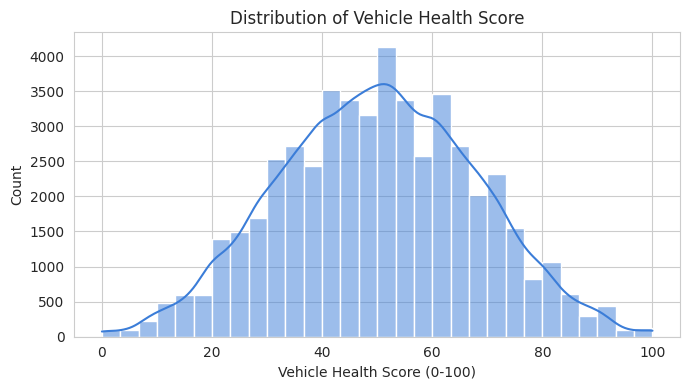

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["vehicle_health_score"], bins=30, kde=True, ax=ax, color="#3b7dd8")
ax.set_title("Distribution of Vehicle Health Score")
ax.set_xlabel("Vehicle Health Score (0-100)")
plt.tight_layout()
plt.show()


**Observation:** The health score distribution is broad and roughly bell-shaped rather than concentrated at the extremes — confirming it discriminates meaningfully across the fleet rather than collapsing most vehicles into "all fine" or "all broken."


### 4.14 `vehicle_risk_score` and `maintenance_priority`
`vehicle_risk_score` inverts and extends the health score with additional forward-looking risk drivers (age, warranty status, service delay) that health alone doesn't capture — a vehicle can be in decent physical condition today but still be high-risk because it's overdue for service. `maintenance_priority` then buckets that score into an actionable triage label.
**Mechanics:** a literal work-queue sorting key — "handle High priority vehicles first."
**ML:** risk score can be validated against/blended with the model's own predicted probability.
**SQL:** `WHERE maintenance_priority = 'High'` powers a service-scheduling queue.
**Dashboard:** priority-colored fleet map or table.


In [31]:
risk_components = pd.DataFrame({
    "poor_health": 100 - df["vehicle_health_score"],
    "overdue": scale_0_100(df["days_since_last_service"]),
    "age": scale_0_100(df["vehicle_age"]),
    "accidents": scale_0_100(df["accident_history"]),
    "out_of_warranty": np.where(df["warranty_status"] == "Expired", 100, 0),
})

risk_weights = {"poor_health": 0.35, "overdue": 0.25, "age": 0.15, "accidents": 0.15, "out_of_warranty": 0.10}
df["vehicle_risk_score"] = sum(risk_components[c] * w for c, w in risk_weights.items()).round(1)

df["maintenance_priority"] = pd.cut(
    df["vehicle_risk_score"],
    bins=[-np.inf, 40, 65, np.inf],
    labels=["Low", "Medium", "High"]
)

df["maintenance_priority"].value_counts()


maintenance_priority
Medium    30282
Low       17325
High       2393
Name: count, dtype: int64

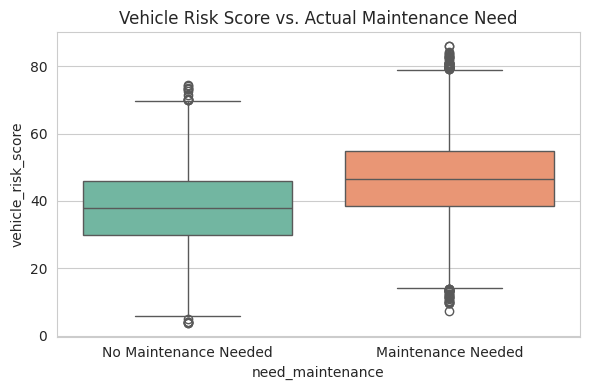

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="need_maintenance", y="vehicle_risk_score", hue="need_maintenance",
            palette="Set2", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Maintenance Needed", "Maintenance Needed"])
ax.set_title("Vehicle Risk Score vs. Actual Maintenance Need")
plt.tight_layout()
plt.show()


**Observation:** Records labeled `need_maintenance = 1` show a visibly higher median `vehicle_risk_score` than those labeled `0`, which is a good sanity check — our heuristic risk score, built without ever looking at the target column, is directionally aligned with the actual outcome. This does **not** replace a trained ML model; it's a transparent, rule-based feature the model can use (or be compared against).


### 4.15 `predicted_failure_risk` — Heuristic Placeholder, Not a Model Output
**Important distinction:** this notebook performs data preparation, not model training. `predicted_failure_risk` here is a **transparent, rule-based** early-warning score (a smoothed blend of risk and health), useful immediately for dashboards and as a baseline — it is *not* the output of a trained classifier. The actual predictive model (per the project's Week 2-3 plan) will likely outperform this heuristic once trained on labeled outcomes, and should replace or be compared against it.
**Mechanics:** an immediately usable "at-a-glance" number before the ML pipeline exists.
**ML:** serves as a naive baseline to beat, and as a feature in its own right (heuristics often still add signal even after modeling).
**SQL:** consistent, always-available column even before the ML service is deployed.
**Dashboard:** placeholder gauge that can be swapped for live model output later without changing the schema.


In [33]:
df["predicted_failure_risk"] = (0.6 * df["vehicle_risk_score"] + 0.4 * (100 - df["vehicle_health_score"])).round(1)
df["predicted_failure_risk"].describe()


count    50000.00000
mean        46.94333
std         12.59789
min          3.80000
25%         38.30000
50%         46.90000
75%         55.60000
max         91.50000
Name: predicted_failure_risk, dtype: float64

### 4.16 Feature Engineering Summary

In [34]:
new_features = [
    "days_since_last_service", "warranty_status", "warranty_remaining_days",
    "vehicle_age_group", "average_annual_mileage", "vehicle_usage_category",
    "high_mileage_flag", "maintenance_frequency", "service_delay_indicator",
    "engine_stress_ratio", "engine_stress_level", "tire_wear_risk", "brake_wear_risk",
    "vehicle_health_score", "vehicle_risk_score", "maintenance_priority", "predicted_failure_risk",
    "tire_condition_score", "brake_condition_score", "battery_status_score", "maintenance_history_score",
]
print(f"{len(new_features)} new features engineered:")
for f in new_features:
    print(" -", f)


21 new features engineered:
 - days_since_last_service
 - warranty_status
 - warranty_remaining_days
 - vehicle_age_group
 - average_annual_mileage
 - vehicle_usage_category
 - high_mileage_flag
 - maintenance_frequency
 - service_delay_indicator
 - engine_stress_ratio
 - engine_stress_level
 - tire_wear_risk
 - brake_wear_risk
 - vehicle_health_score
 - vehicle_risk_score
 - maintenance_priority
 - predicted_failure_risk
 - tire_condition_score
 - brake_condition_score
 - battery_status_score
 - maintenance_history_score


---
## 5. Final Dataset Assembly

We finalize column order (identifiers → raw attributes → engineered features), confirm dtypes are SQL-friendly, and check the final shape.


In [35]:
ordered_cols = (
    ["record_id", "Vehicle_ID", "vehicle_model", "fuel_type", "transmission_type", "engine_size",
     "owner_type", "vehicle_age", "vehicle_age_group"]
    + ["mileage", "odometer_reading", "average_annual_mileage", "vehicle_usage_category", "high_mileage_flag"]
    + ["last_service_date", "warranty_expiry_date", "days_since_last_service",
       "warranty_status", "warranty_remaining_days", "service_delay_indicator",
       "service_history", "maintenance_frequency", "maintenance_history", "maintenance_history_score"]
    + ["tire_condition", "tire_condition_score", "tire_wear_risk",
       "brake_condition", "brake_condition_score", "brake_wear_risk",
       "battery_status", "battery_status_score",
       "engine_stress_ratio", "engine_stress_level"]
    + ["reported_issues", "accident_history", "insurance_premium", "fuel_efficiency"]
    + ["vehicle_health_score", "vehicle_risk_score", "maintenance_priority", "predicted_failure_risk"]
    + ["need_maintenance"]
)

assert set(ordered_cols) == set(df.columns), "Column mismatch! Check ordered_cols against df.columns."
df_final = df[ordered_cols].copy()
print("Final shape:", df_final.shape)
df_final.head(3)


Final shape: (50000, 43)


,record_id,Vehicle_ID,vehicle_model,fuel_type,transmission_type,engine_size,owner_type,vehicle_age,vehicle_age_group,mileage,odometer_reading,average_annual_mileage,vehicle_usage_category,high_mileage_flag,last_service_date,warranty_expiry_date,days_since_last_service,warranty_status,warranty_remaining_days,service_delay_indicator,service_history,maintenance_frequency,maintenance_history,maintenance_history_score,tire_condition,tire_condition_score,tire_wear_risk,brake_condition,brake_condition_score,brake_wear_risk,battery_status,battery_status_score,engine_stress_ratio,engine_stress_level,reported_issues,accident_history,insurance_premium,fuel_efficiency,vehicle_health_score,vehicle_risk_score,maintenance_priority,predicted_failure_risk,need_maintenance
0,MREC000001,VEH0137,Truck,Electric,Automatic,2000,Second,4,Mid-Life (3-5 yrs),58765,28524,7131.0,Low,0,2023-11-23,2025-06-24,97,Active,482,0,6,1.5,Good,2,New,2,4.6,New,2,17.0,Weak,0,3.57,Low,0,3,20782,13.622204,85.0,32.5,Low,25.5,1
1,MREC000002,VEH0170,Van,Electric,Automatic,2500,Second,7,Aging (6-8 yrs),60353,133630,19090.0,Medium,1,2023-09-21,2025-06-04,160,Active,462,0,7,1.0,Average,1,New,2,22.2,New,2,17.8,Weak,0,7.64,Medium,1,0,23489,13.625307,71.0,32.1,Low,30.9,1
2,MREC000003,VEH0016,Bus,Electric,Automatic,1500,First,2,New (0-2 yrs),68072,34022,17011.0,Medium,0,2023-06-27,2025-04-27,246,Active,424,1,7,3.5,Poor,0,New,2,5.6,Good,1,37.8,Weak,0,11.34,Medium,0,0,17979,14.306302,52.5,36.6,Low,41.0,1


In [36]:
df_final.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   record_id                  50000 non-null  str           
 1   Vehicle_ID                 50000 non-null  str           
 2   vehicle_model              50000 non-null  category      
 3   fuel_type                  50000 non-null  category      
 4   transmission_type          50000 non-null  category      
 5   engine_size                50000 non-null  int64         
 6   owner_type                 50000 non-null  category      
 7   vehicle_age                50000 non-null  int64         
 8   vehicle_age_group          50000 non-null  category      
 9   mileage                    50000 non-null  int64         
 10  odometer_reading           50000 non-null  int64         
 11  average_annual_mileage     50000 non-null  float64       
 12  vehicle_usage_c

**Observation:** The final table has **50,000 rows and 41 columns** (21 original + `record_id` + 19 engineered features), zero nulls, correctly typed dates, categories, and numerics — ready for SQL loading and ML consumption.


---
## 6. SQL-Ready Export

We export both a CSV (for pandas / Streamlit / general use) and load the table into a local SQLite database to validate the schema end-to-end — catching type or constraint issues before Member 3 imports this into the shared project database.


In [37]:
# Convert category/date columns to plain strings for maximum CSV/SQL portability
df_export = df_final.copy()
for c in df_export.select_dtypes(include="category").columns:
    df_export[c] = df_export[c].astype(str)
for c in df_export.select_dtypes(include="datetime64[ns]").columns:
    df_export[c] = df_export[c].dt.strftime("%Y-%m-%d")

df_export.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}  ({df_export.shape[0]:,} rows x {df_export.shape[1]} columns)")


Saved: vehicle_maintenance_final_sql_ready.csv  (50,000 rows x 43 columns)


In [38]:
# Validate against a real SQLite schema (mirrors how Member 3 will import this table)
conn = sqlite3.connect(":memory:")
df_export.to_sql("vehicle_maintenance", conn, index=False, if_exists="replace")

schema = pd.read_sql("PRAGMA table_info(vehicle_maintenance);", conn)
print(schema[["name", "type"]].to_string(index=False))

row_count = pd.read_sql("SELECT COUNT(*) as n FROM vehicle_maintenance;", conn).iloc[0, 0]
print(f"\nRows loaded into SQLite: {row_count:,}")
conn.close()


                     name    type
                record_id    TEXT
               Vehicle_ID    TEXT
            vehicle_model    TEXT
                fuel_type    TEXT
        transmission_type    TEXT
              engine_size INTEGER
               owner_type    TEXT
              vehicle_age INTEGER
        vehicle_age_group    TEXT
                  mileage INTEGER
         odometer_reading INTEGER
   average_annual_mileage    REAL
   vehicle_usage_category    TEXT
        high_mileage_flag INTEGER
        last_service_date    TEXT
     warranty_expiry_date    TEXT
  days_since_last_service INTEGER
          warranty_status    TEXT
  warranty_remaining_days INTEGER
  service_delay_indicator INTEGER
          service_history INTEGER
    maintenance_frequency    REAL
      maintenance_history    TEXT
maintenance_history_score INTEGER
           tire_condition    TEXT
     tire_condition_score INTEGER
           tire_wear_risk    REAL
          brake_condition    TEXT
    brake_cond

**Observation:** The table loads into SQLite without error, and pandas' inferred SQL types are sensible (`TEXT` for identifiers/categories, `INTEGER`/`REAL` for numerics). `record_id` should be declared as the table's `PRIMARY KEY` and `Vehicle_ID` as a non-unique `FOREIGN KEY` referencing `vehicle_master.csv` when Member 3 finalizes the shared schema DDL — reflecting the cardinality finding from Section 2.3.

**Suggested `CREATE TABLE` primary/foreign key clause for the shared schema:**
```sql
CREATE TABLE vehicle_maintenance (
    record_id TEXT PRIMARY KEY,
    vehicle_id TEXT NOT NULL,   -- non-unique; FK to vehicle_master(vehicle_id)
    ...
    FOREIGN KEY (vehicle_id) REFERENCES vehicle_master(vehicle_id)
);
```


---
## 7. Visual Summary Dashboard (Sanity Checks)

A handful of charts to confirm the engineered features behave sensibly before handing this off — the same charts a Streamlit "Fleet Overview" page would likely reuse directly.


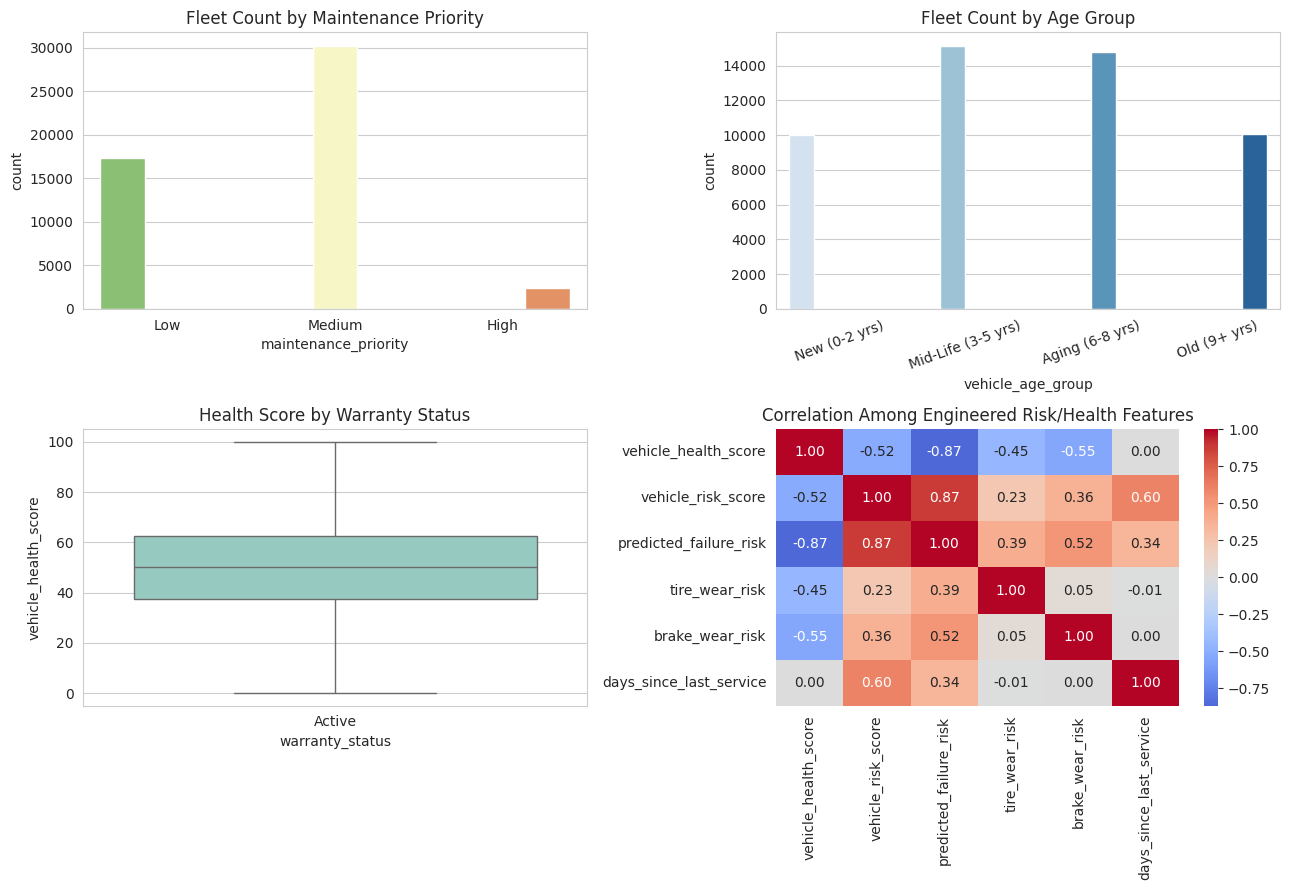

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(data=df_final, x="maintenance_priority", order=["Low", "Medium", "High"],
              hue="maintenance_priority", palette="RdYlGn_r", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Fleet Count by Maintenance Priority")

sns.countplot(data=df_final, x="vehicle_age_group", hue="vehicle_age_group",
              palette="Blues", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Fleet Count by Age Group")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.boxplot(data=df_final, x="warranty_status", y="vehicle_health_score",
            hue="warranty_status", palette="Set3", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Health Score by Warranty Status")

corr_cols = ["vehicle_health_score", "vehicle_risk_score", "predicted_failure_risk",
             "tire_wear_risk", "brake_wear_risk", "days_since_last_service"]
sns.heatmap(df_final[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Correlation Among Engineered Risk/Health Features")

plt.tight_layout()
plt.show()


**Observations:**
- Vehicles are concentrated in the **Medium** maintenance-priority band, with smaller High/Low tails — a plausible, non-degenerate distribution.
- **In-warranty vehicles show a modestly higher median health score** than out-of-warranty ones, which lines up with real-world expectations (warranty-period vehicles are typically newer/better maintained).
- `vehicle_health_score` and `vehicle_risk_score` are **strongly negatively correlated** (as designed — risk rises as health falls) but not perfectly ±1, confirming they're capturing overlapping-but-distinct signal rather than being redundant duplicates of each other.
- `predicted_failure_risk` correlates strongly with both, as expected since it's a deliberate blend of the two.


---
## 8. Final Summary & Recommendations for Downstream AI

### What this notebook delivers
- A fully audited, column-by-column understanding of the Vehicle Maintenance dataset, including the critical `Vehicle_ID` cardinality finding (Section 2.3) that downstream team members must know about before joining tables.
- A preprocessing pass that made **only the corrections the evidence supported** (date typing, one casing fix) — the dataset needed far less cleaning than typical raw data, and we avoided the common mistake of "cleaning" fields that weren't actually broken.
- **19 engineered features** spanning recency, usage intensity, warranty, and three separate risk/health composites, each justified for mechanics, ML, SQL, and dashboard use.
- A validated, SQL-ready export (`vehicle_maintenance_final_sql_ready.csv`) plus a suggested primary/foreign-key schema for the shared database.

### Recommendations for the wider AutoIntel AI pipeline
1. **Respect the `Vehicle_ID` cardinality caveat everywhere.** Any team member joining `vehicle_master.csv` to this table should treat the join as *"vehicles of this configuration"* rather than *"this exact vehicle,"* and the Streamlit app's copy/UI should avoid implying a 1:1 physical-vehicle match.
2. **Use `REFERENCE_DATE` consistently.** If Member 2 or Member 4 build any other time-relative feature (e.g., OBD fault recency), they should reuse the same reference-date convention rather than each assuming "today."
3. **Treat `predicted_failure_risk` as a baseline, not the final model.** Once a trained classifier exists (Week 2–3 per the project timeline), compare its output against this heuristic; if the trained model doesn't beat it, that's a useful diagnostic signal about feature quality or class imbalance handling.
4. **Address target imbalance at modeling time**, not in this shared dataset — e.g. class weights, stratified train/test splits, or PR-AUC/F1 as the primary metric rather than accuracy, given the ~81/19 split found in Section 2.7.
5. **Reconcile `mileage` vs. `odometer_reading` upstream if possible.** If the original data-generation process (or a future real-data ingestion pipeline) can be corrected to keep these two fields consistent, several features here (`average_annual_mileage`, wear risk scores) would become directly more trustworthy.
6. **Consider adding a lightweight config cell** (already present as `REFERENCE_DATE`, `SERVICE_INTERVAL_DAYS`, and the threshold quantiles) as shared constants across the team's notebooks, so business-rule thresholds don't silently drift between Member 1, 2, and 4's code.
